In [18]:
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt

### ARMA Time Series Forecasting

In [19]:
start = dt.datetime(2021,7,1)
end = dt.datetime(2022,1,27)

symbol = "INFY.NS"
stockData = yf.download(symbol,start=start,end=end)
stockData.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS
Date,,,,,
2021-07-01,1359.065430,1373.392884,1357.889638,1373.392884,4814317
2021-07-02,1365.510742,1366.947762,1343.562171,1357.802550,5166064
2021-07-05,1375.221924,1380.491350,1359.631602,1366.686458,4058338
2021-07-06,1360.633179,1382.015596,1356.191240,1370.649362,4089574
2021-07-07,1362.723633,1367.905983,1345.347773,1363.986607,4797120


In [20]:
stockData = stockData[["Open","High","Low","Close"]]
stockData.head()

Price,Open,High,Low,Close
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS
Date,,,,
2021-07-01,1373.392884,1373.392884,1357.889638,1359.065430
2021-07-02,1357.802550,1366.947762,1343.562171,1365.510742
2021-07-05,1366.686458,1380.491350,1359.631602,1375.221924
2021-07-06,1370.649362,1382.015596,1356.191240,1360.633179
2021-07-07,1363.986607,1367.905983,1345.347773,1362.723633


In [21]:
from sklearn.preprocessing import MinMaxScaler

Ms = MinMaxScaler()
data1 = Ms.fit_transform(stockData[["Close"]])
print("Dataset Shape :",data1.shape)

Dataset Shape : (143, 1)


In [22]:
from statsmodels.tsa.arima.model import ARIMA

orders = [(1,0,1),(1,0,2),(2,0,1),(2,0,2)]

best_model = None
best_rmse = 999999

from sklearn.metrics import mean_squared_error
for order in orders:
    model = ARIMA(data1,order=order)
    model_fit = model.fit()
    y_pred = model_fit.predict(0,len(data1)-1)

    rmse = np.sqrt(mean_squared_error(data1,y_pred))
    print(order," RMSE =",rmse)
    if rmse < best_rmse:
        best_rmse = rmse
        best_model = model_fit
        best_order = order

(1, 0, 1)  RMSE = 0.06048836077424372
(1, 0, 2)  RMSE = 0.06041332194785329
(2, 0, 1)  RMSE = 0.06041302455541446
(2, 0, 2)  RMSE = 0.060481794663425154


c:\Users\Paul\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Paul\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [23]:
print("Best Order :",best_order)
print("Best RMSE :",best_rmse)

Best Order : (2, 0, 1)
Best RMSE : 0.06041302455541446


In [24]:
y_pred = best_model.predict(0,len(data1)-1)

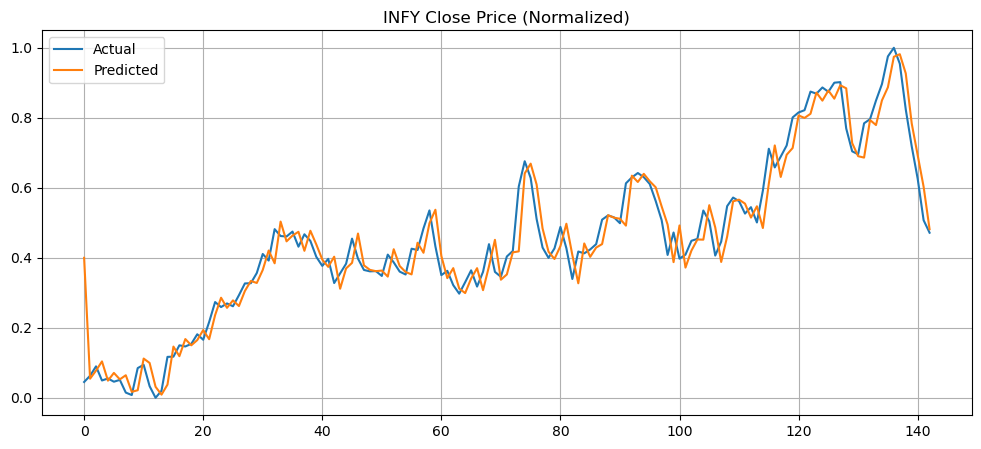

In [25]:
plt.figure(figsize=(12,5))
plt.plot(data1,label="Actual")
plt.plot(y_pred,label="Predicted")
plt.title("INFY Close Price (Normalized)")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
actual = Ms.inverse_transform(data1)
pred = Ms.inverse_transform(np.array(y_pred).reshape(-1,1))

In [27]:
actual_df = pd.DataFrame(actual,columns=["Close"])
pred_df = pd.DataFrame(pred,columns=["Close"])
actual_df.head()

,Close
0,1359.065430
1,1365.510742
2,1375.221924
3,1360.633179
4,1362.723633


In [28]:
from sklearn.metrics import mean_absolute_error

rmse = np.sqrt(mean_squared_error(actual_df,pred_df))
mae = mean_absolute_error(actual_df,pred_df)
print("RMSE :",rmse)
print("MAE :",mae)

RMSE : 21.835908669223738
MAE : 15.81511672022812


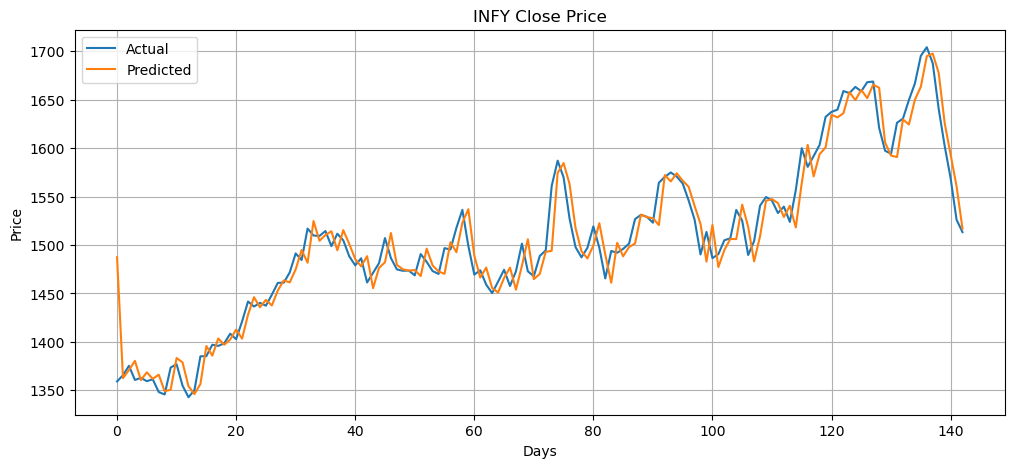

In [29]:
plt.figure(figsize=(12,5))
plt.plot(actual_df,label="Actual")

plt.plot(pred_df,label="Predicted")
plt.title("INFY Close Price")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
forecast = best_model.predict(len(data1),len(data1)+4)
forecast

array([0.46891068, 0.46634863, 0.46387782, 0.46149932, 0.45920921])

In [31]:
forecast_price = Ms.inverse_transform(np.array(forecast).reshape(-1,1))
forecast_df = pd.DataFrame(forecast_price,columns=["Forecast"])
forecast_df

,Forecast
0,1512.263143
1,1511.337106
2,1510.444047
3,1509.584355
4,1508.756607


In [32]:
forecast_df.to_csv("INFY_ARMA_Forecast.csv",index=False)
print("ARMA Forecast Completed Successfully.")

ARMA Forecast Completed Successfully.
